In [2398]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import re
from pathlib import Path
sns.set_theme()

## Original Violin plots Paper for 100 Samples 

In [2399]:
# old parts of the code that define mappings and lists
llm_map = {
    'id': 'id', 
    'CV': 'No Manipulation', 
    'Claude-3.5-Sonnet': 'Claude-3.5-Sonnet', 
    'Clean_Deepseek_67B': 'DeepSeek-67B',
    'Clean_Deepseek_V3': 'DeepSeek-V3',
    'GPT-3.5-Turbo': 'GPT-3.5-Turbo', 
    'GPT4o-mini': 'GPT4o-mini', 
    'GPT4o':  'GPT4o', 
    'Llama3-70B-Instruct-Turbo': 'Llama3-70B-Instruct-Turbo', 
    'Mixtral-8x7B-Instruct': 'Mixtral-8x7B-Instruct', 
}

job_map = {
    'DD_PM': 'DoorDash Product Manager', 
    'DD' : 'DoorDash Product Manager', # added this because of own name conventions
    'Apple_PM': 'Apple Product Manager', 
    'Match_PM': 'Match Product Manager', 
    'Samsara_PM': 'Samsara Product Manager', 
    'Yelp_PM': 'Yelp Product Manager',
    'Adobe_UX': 'Adobe UX Designer', 
    'Amazon_UX': 'Amazon UX Designer', 
    'Google_UX': 'Google UX Designer',
    'GG': 'Google UX Designer',   # added this because of own name conventions
    'I2C_UX': 'I2C UX Designer', 
    'Rowan_UX': 'Rowan UX Designer', 
}

models_list = ['No Manipulation', 'Claude-3.5-Sonnet', 'DeepSeek-67B', 'DeepSeek-V3',
               'GPT-3.5-Turbo', 'GPT4o-mini', 'GPT4o','Llama3-70B-Instruct-Turbo', 'Mixtral-8x7B-Instruct']


In [2400]:
# single plot
job_str = 'Google_UX'
scores_df = pd.read_csv(f'Figure1_100Samples/Scores/Scores-{job_str}-Resumes.csv')

In [2401]:
scores_df.columns = scores_df.columns.str.rsplit(' ', n=2).str[0]
scores_df.columns = scores_df.columns.map(llm_map)
scores_df['True Label'] = scores_df['id']>49
scores_df['True Label'] = scores_df['True Label'].astype(int)

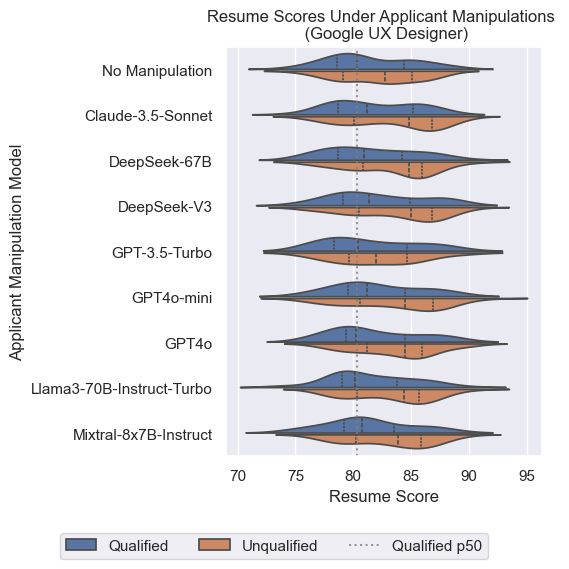

In [2402]:
fig, ax = plt.subplots(figsize=(6, 6))
melted_df = pd.melt(scores_df, 
                    # Keep b and i as id variables
                    id_vars=['True Label'],
                    # Select the CR columns to melt
                    value_vars=models_list,
                    # Name the new columns
                    var_name='LLM',
                    value_name='Resume Score')

melted_df['Ground Truth'] = melted_df['True Label'].map({0:'Unqualified', 1:'Qualified'})
qualified_mean = scores_df[scores_df['True Label'] == 1]['No Manipulation'].median()
sns.violinplot(data=melted_df, x='Resume Score', y='LLM', 
               hue='Ground Truth', split='true', 
               hue_order=['Qualified', 'Unqualified'], 
               inner='quart', gap=0.1)
plt.axvline(x=qualified_mean, color='gray', linestyle=':', alpha=0.8, label='Qualified p50')
plt.ylabel('Applicant Manipulation Model')
plt.title(f"Resume Scores Under Applicant Manipulations \n ({job_map[job_str]})")
plt.legend(bbox_to_anchor=(-0.55, -0.27), loc='lower left', ncol=3)
plt.tight_layout()
plt.savefig(f"img/{job_str}_1round.pdf")

## Reproducibility & Extension Violin Plots 

In [2403]:
# new maps for our reproduction/extension data 
# old models 
llm_map_old = {
    'id': 'id', 
    'CV': 'No Manipulation', 
    'sonnet': 'Claude-4.5-sonnet', 
    'sonnet2': 'Claude-4.5-sonnet.2', 
    'DS1': 'DeepSeek-V3',
    'DS2' : 'DeepSeek-V3.2',
    'DS3' : 'DeepSeek-V3.3',
    'GPT-3.5.1': 'GPT-3.5', 
    'GPT-3.5.2': 'GPT-3.5.2',
    'GPT-3.5.3': 'GPT-3.5.3',
    'GPT-mini1': 'GPT4o-mini', 
    'GPT-mini2': 'GPT-4o-mini.2', 
    'GPT-mini3': 'GPT-4o-mini.3', 
    'GPT-4o1': 'GPT-4o', 
    'GPT-4o2': 'GPT-4o.2', 
    'GPT-4o3': 'GPT-4o.3', 
    'Llama1': 'Llama-3.3-70b-Instruct', 
    'Llama2': 'Llama-3.3-70b-instruct.2', 
    'Llama3': 'Llama-3.3-70b-instruct.3', 
    'Mixtral1': 'Mixtral-8x7b-Instruct', 
    'Mixtral2': 'Mixtral-8x7b-instruct.2', 
    'Mixtral3': 'Mixtral-8x7b-instruct.3', 
    'True': 'True Label'
}
models_list_old = ['No Manipulation', 'Claude-4.5-sonnet', 'DeepSeek-V3',  'GPT-3.5', 'GPT4o-mini','GPT-4o', 'Llama-3.3-70b-Instruct', 'Mixtral-8x7b-Instruct']


# new models 
llm_map_new = {
    'CV' : 'No Manipulation',
    'haiku' : 'haiku',
    'sonnet' : 'claude-4.5-sonnet',
    'gemini_flash' : 'gemini_flash',
    'opus' : 'opus',
    'gemini_pro' : 'gemini_pro',
    'gemini_flash_lite' : 'gemini_flash_lite', 
    'True' : 'True Label'
}
models_list_new = ['No Manipulation',  'claude-4.5-sonnet','opus', 'haiku', 'gemini_flash', 'gemini_flash_lite' ,'gemini_pro', 'True Label' ]

# mix 
llm_map_mix = {
    'CV' : 'No Manipulation',
       'gpt_4o' : 'GPT-4o',  
       'gpt_mini' : 'GPT-4o-mini',
       'gpt_3.5' : 'GPT3.5', 
       'gpt4o_twice' : 'gpt4o on gpt4o',
       '4o_on_35' : 'gpt4o on 3.5',  
       '4o_on_mini' : 'gpt4o on mini', 
       'True' : 'True Label',
}
models_list_mix = ['No Manipulation',  'gpt5.2 on claude', 'gpt4o on 3.5', 'gpt4o on mini', 'True Label' ]

In [2404]:

# single plot depending on file 
# select for desired data 
job_str = 'DD'
job_str = 'GG'

BASE_DIR = Path(f'/Users/nicky/Desktop/FACT/DatasetsFinal/')
score_set = "old"   # "new" or "old"
model_set = "old"   # "new" or "old"
UK_data = False

score_prefix = {"new": "N", "old": "O"}[score_set]
model_prefix = {"new": "N", "old": "O"}[model_set]


filename = f"{score_prefix}Scores-{model_prefix}{job_str}-LAST?.csv"
path = BASE_DIR / filename
if not path.exists():
    raise FileNotFoundError(f"Missing file: {path}")

new_df = pd.read_csv(BASE_DIR / filename)

# Ukrainian data
if UK_data: 
    new_df = pd.read_csv(f"/Users/nicky/Desktop/FACT/Nicky/Ukrainian/ScoresLieve/DoorDashPM_newscores.csv")
    new_df = pd.read_csv(f"/Users/nicky/Desktop/FACT/Nicky/Ukrainian/ScoresLieve/GoogleUX_newscores.csv")


llm_map = llm_map_new if model_set == "new" else llm_map_old
models_list = models_list_new if model_set == "new" else models_list_old
new_df.columns = new_df.columns.str.rsplit(' ', n=2).str[0]
new_df.columns = new_df.columns.map(llm_map)



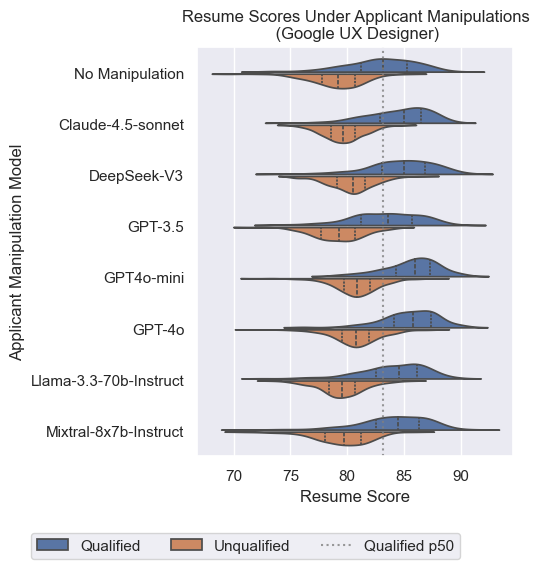

In [2405]:
fig, ax = plt.subplots(figsize=(6, 6))
melted_df = pd.melt(new_df, 
                    # Keep b and i as id variables
                    id_vars=['True Label'],
                    # Select the CR columns to melt
                    value_vars=models_list,
                    # Name the new columns
                    var_name='LLM',
                    value_name='Resume Score')

melted_df['Ground Truth'] = melted_df['True Label'].map({0:'Unqualified', 1:'Qualified'}) # DD
qualified_mean = new_df[new_df['True Label'] == 1]['No Manipulation'].median()
sns.violinplot(data=melted_df, x='Resume Score', y='LLM', 
               hue='Ground Truth', split='true', 
               hue_order=['Qualified', 'Unqualified'], 
               inner='quart', gap=0.1)
plt.axvline(x=qualified_mean, color='gray', linestyle=':', alpha=0.8, label='Qualified p50')
plt.ylabel('Applicant Manipulation Model')
plt.title(f"Resume Scores Under Applicant Manipulations\n ({job_map[job_str]})")
plt.legend(bbox_to_anchor=(-0.55, -0.27), loc='lower left', ncol=3)
plt.tight_layout()
plt.savefig(f"img/{job_str}_1.1round.pdf")

## Two Manipulations vs One Manipulation
This is completely our own and improved plotting function for determinging stagnation. 
These plot are only for the old models so have to set model_set = "old" and score_set = "old" above

In [2406]:
# own codes 
manipulation_dd_map = { 
    'Claude-4.5-sonnet': 1,
    'Claude-4.5-sonnet.2': 2,
    'DeepSeek-V3': 1,
    'DeepSeek-V3.2': 2,
    'DeepSeek-V3.3': 3,
    'GPT-3.5': 1, 
    'GPT-3.5.2': 2,
    'GPT-3.5.3': 3,
    'GPT-4o-mini': 1,
    'GPT-4o-mini.2': 2,
    'GPT-4o-mini.3': 3,
    'GPT-4o.1': 1, 
    'GPT-4o.2': 2,
    'GPT-4o.3': 3,
    'Llama-3.3-70b-instruct': 1, 
    'Llama-3.3-70b-instruct.2': 2,
    'Llama-3.3-70b-instruct.3': 3,
    'Mixtral-8x7b-instruct': 1, 
    'Mixtral-8x7b-instruct.2': 2,
    'Mixtral-8x7b-instruct.3': 3,
    'True': 'True'
}

models_list = ['True', 'DeepSeek-V3','DeepSeek-V3.2','DeepSeek-V3.3',
    'Claude-4.5-sonnet', 'Claude-4.5-sonnet.2',
    'GPT-3.5', 'GPT-3.5.2', 'GPT-3.5.3'
    'GPT-4o-mini','GPT-4o-mini.2', 'GPT-4o-mini.3',
    'GPT-4o','GPT-4o.2','GPT-4o.3', 
    'Llama-3.3-70b-instruct','Llama-3.3-70b-instruct.2', 'Llama-3.3-70b-instruct.3', 
    'Mixtral-8x7b-instruct','Mixtral-8x7b-instruct.2','Mixtral-8x7b-instruct.3'
    ]

In [2407]:
# plots only for old scores and model 
filename = f"OScores-O{job_str}-LAST?.csv"
path = BASE_DIR / filename
if not path.exists():
    raise FileNotFoundError(f"Missing file: {path}")

doordash_df  = pd.read_csv(BASE_DIR / filename)

# Clean headers
doordash_df.columns = doordash_df.columns.str.strip()
doordash_df.columns = doordash_df.columns.str.rsplit(" ", n=2).str[0]
doordash_df.columns = doordash_df.columns.map(llm_map)

In [2408]:
print(doordash_df.columns.tolist())

['id', 'GPT-4o', 'GPT-4o.3', 'GPT-4o.2', 'GPT-3.5', 'GPT-3.5.3', 'GPT-3.5.2', 'Mixtral-8x7b-instruct.2', 'Mixtral-8x7b-instruct.3', 'Mixtral-8x7b-Instruct', 'Claude-4.5-sonnet.2', 'Claude-4.5-sonnet', 'Llama-3.3-70b-Instruct', 'Llama-3.3-70b-instruct.3', 'Llama-3.3-70b-instruct.2', 'DeepSeek-V3.2', 'DeepSeek-V3.3', 'DeepSeek-V3', 'GPT4o-mini', 'GPT-4o-mini.2', 'GPT-4o-mini.3', 'No Manipulation', 'True Label']


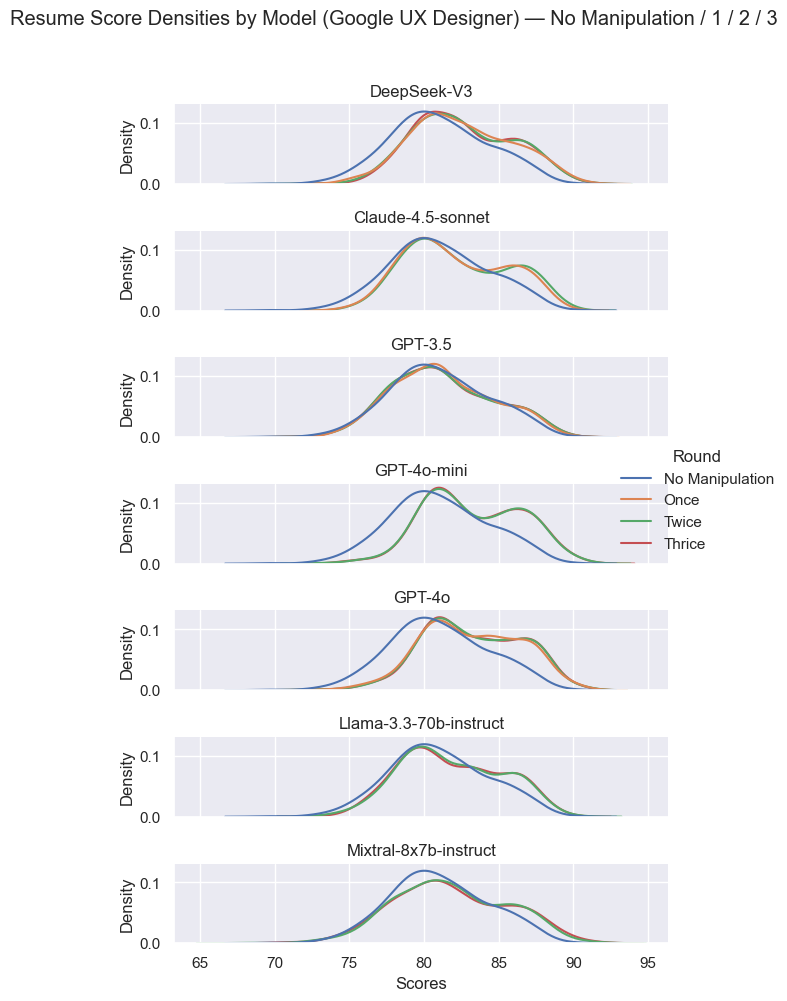

In [2415]:
# original models 
base_models = [
    "DeepSeek-V3",
    "Claude-4.5-sonnet",
    "GPT-3.5",
    "GPT-4o-mini",
    "GPT-4o",
    "Llama-3.3-70b-instruct",
    "Mixtral-8x7b-instruct"
]

round_label = {0: "No Manipulation", 1: "Once", 2: "Twice", 3: "Thrice"}

rows = []
for base in base_models:
    for r in [0, 1, 2, 3]:
        if r == 0:
            col = 'No Manipulation'
        elif r == 1:
            col = base
        else:
            col = f"{base}.{r}"

        if col in doordash_df.columns:
            s = pd.to_numeric(doordash_df[col], errors="coerce")
            rows.append(pd.DataFrame({
                "Score": s,
                "Round": round_label[r],
                "Model": base
            }))

plot_df = pd.concat(rows, ignore_index=True).dropna()

g = sns.displot(
    data=plot_df,
    x="Score",
    hue="Round",
    row="Model",
    kind="kde",
    fill=False,
    common_norm=False,
    height=1.4,
    aspect=3
)
g.set_axis_labels("Scores", "Density")
g.set_titles(row_template="{row_name}")
plt.suptitle(f"Resume Score Densities by Model ({job_map[job_str]}) — No Manipulation / 1 / 2 / 3", y=1.02)
plt.tight_layout()
plt.show()


In [2410]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_pipeline_kde(steps, title, bw_adjust=0.6):

    rows = []
    for st in steps:
        df = pd.read_csv(st["path"])

        # col can be a name (str) or position (int)
        if isinstance(st["col"], int):
            series = df.iloc[:, st["col"]]   # e.g. 1 = second column
        else:
            series = df[st["col"]]

        s = pd.to_numeric(series, errors="coerce")
        rows.append(pd.DataFrame({"Score": s, "Step": st["label"]}))

    plot_df = pd.concat(rows, ignore_index=True).dropna()

    sns.set_theme(rc={"figure.figsize": (20, 10)}, style="darkgrid")
    ax = sns.kdeplot(data=plot_df, x="Score", hue="Step",
                     common_norm=False, bw_adjust=bw_adjust)

    ax.set_title(title, fontsize=22, fontweight="bold")
    ax.set_xlabel("Scores", fontsize=16, fontweight="bold")
    ax.set_ylabel("Density", fontsize=16, fontweight="bold")

    plt.tight_layout()
    plt.show()

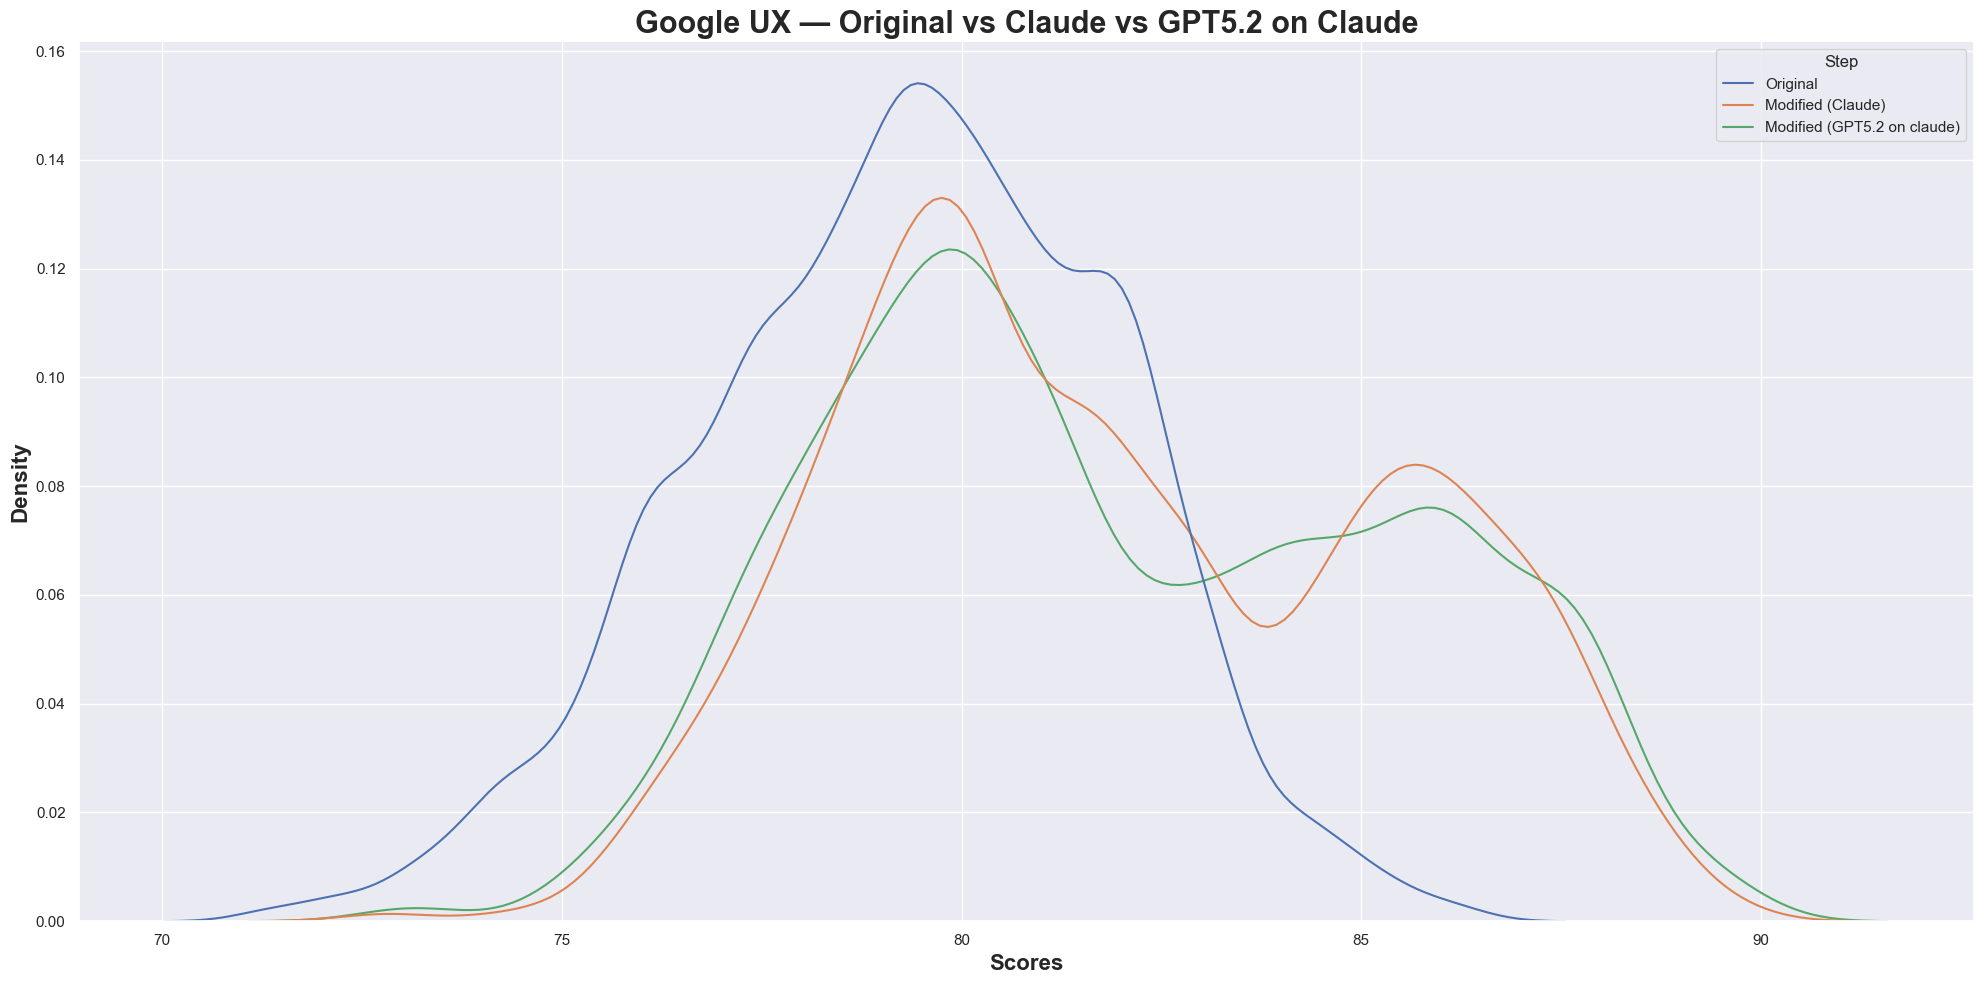

In [2411]:
plot1_steps = [
    {"label": "Original",        "path": "/Users/nicky/Desktop/FACT/Nicky/Scored_520/Combined_DD/ScoresDoorDash_Original_File_merged.csv",      "col": 1},
    {"label": "Modified (Claude)",  "path": "/Users/nicky/Desktop/FACT/Nicky/Scored_520/ScoresUIUX_Original_File_sonnet_google_ux.csv",   "col": 1},
    {"label": "Modified (GPT5.2 on claude)",       "path": '/Users/nicky/Desktop/FACT/Nicky/Scored_520/ScoresUIUX_Original_File_gpt5.2-onclaude.csv',      "col": 1},
]

plot_pipeline_kde(
    plot1_steps,
    title="Google UX — Original vs Claude vs GPT5.2 on Claude",
)

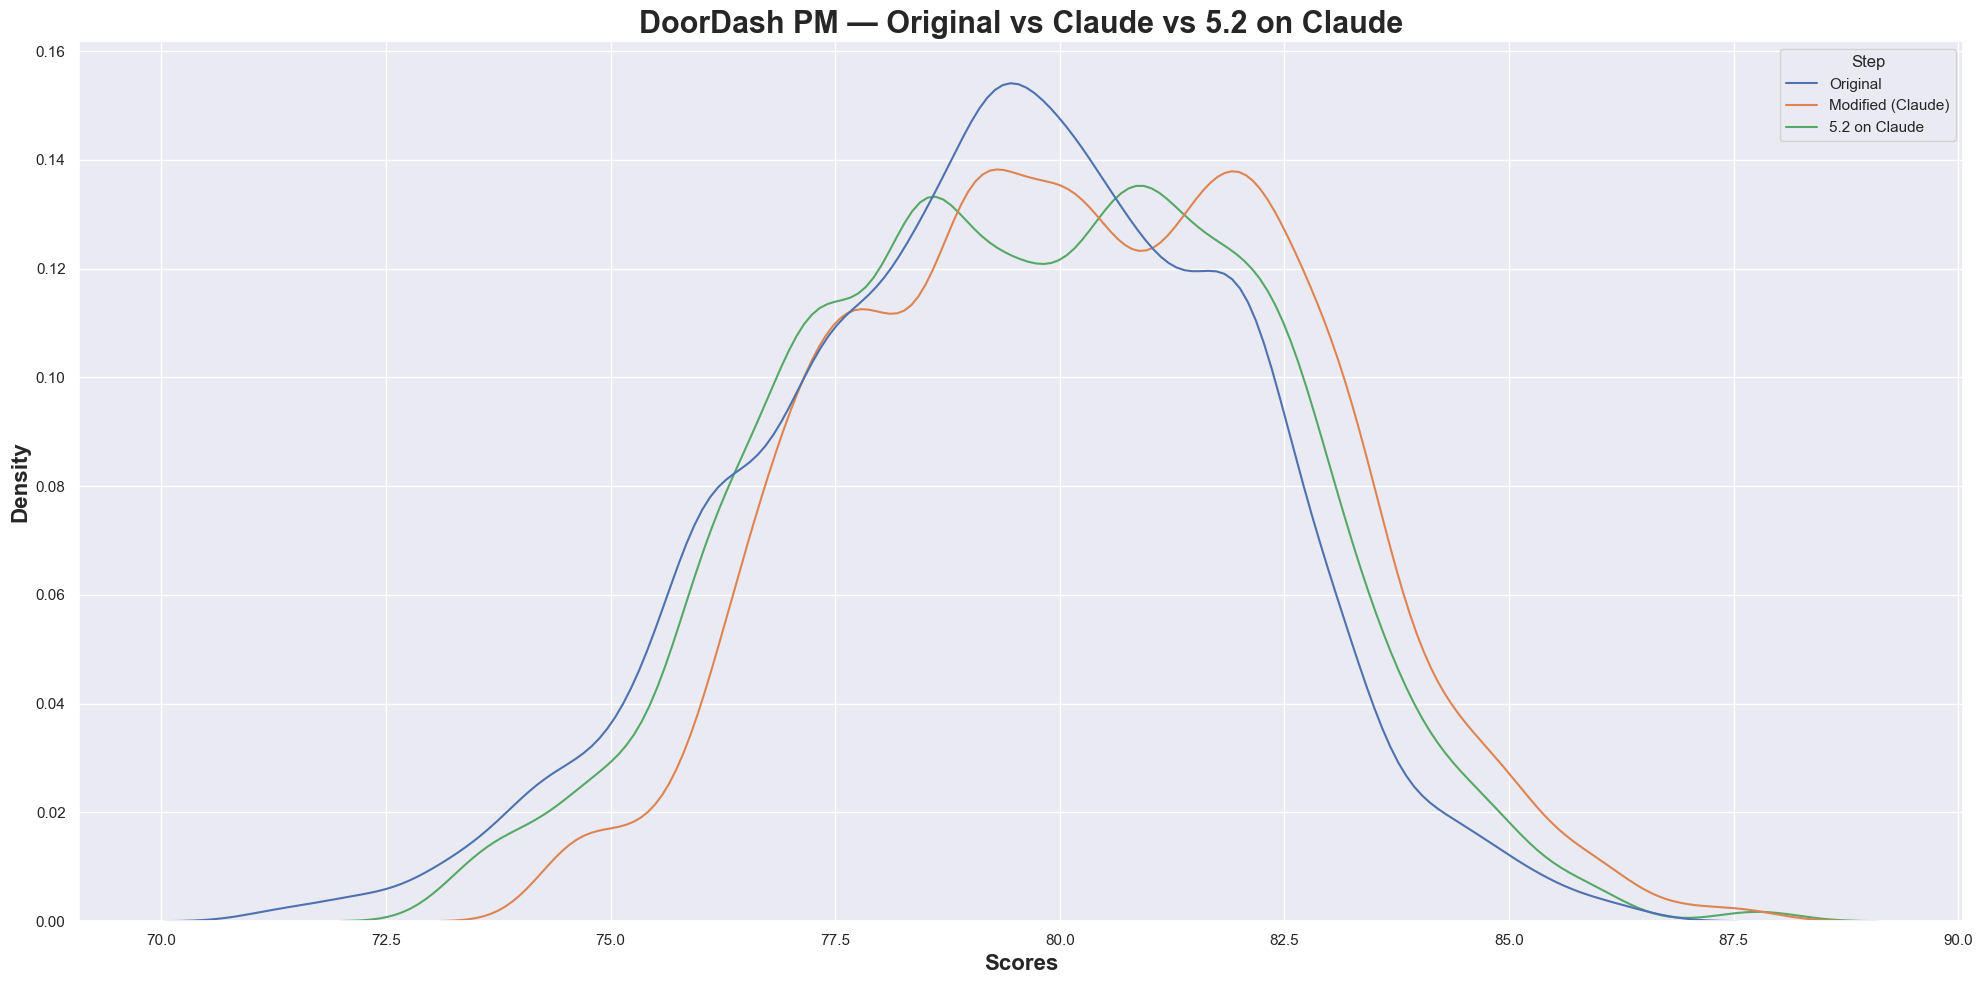

In [2412]:
plot3_steps = [
    {"label": "Original",            "path": "/Users/nicky/Desktop/FACT/Nicky/Scored_520/Combined_DD/ScoresDoorDash_Original_File_merged.csv",     "col": 1},
    {"label": "Modified (Claude)",   "path": "/Users/nicky/Desktop/FACT/Nicky/Scored_520/Combined_DD/ScoresDoorDash_Original_File_sonnet_doordash_pm.csv","col": 1},
    {"label": "5.2 on Claude",       "path": "/Users/nicky/Desktop/FACT/Nicky/Scored_520/ScoresDoorDash_Original_File_gpt5.2-onclaude.csv", "col": 1},
]

plot_pipeline_kde(
    plot3_steps,
    title="DoorDash PM — Original vs Claude vs 5.2 on Claude",
)


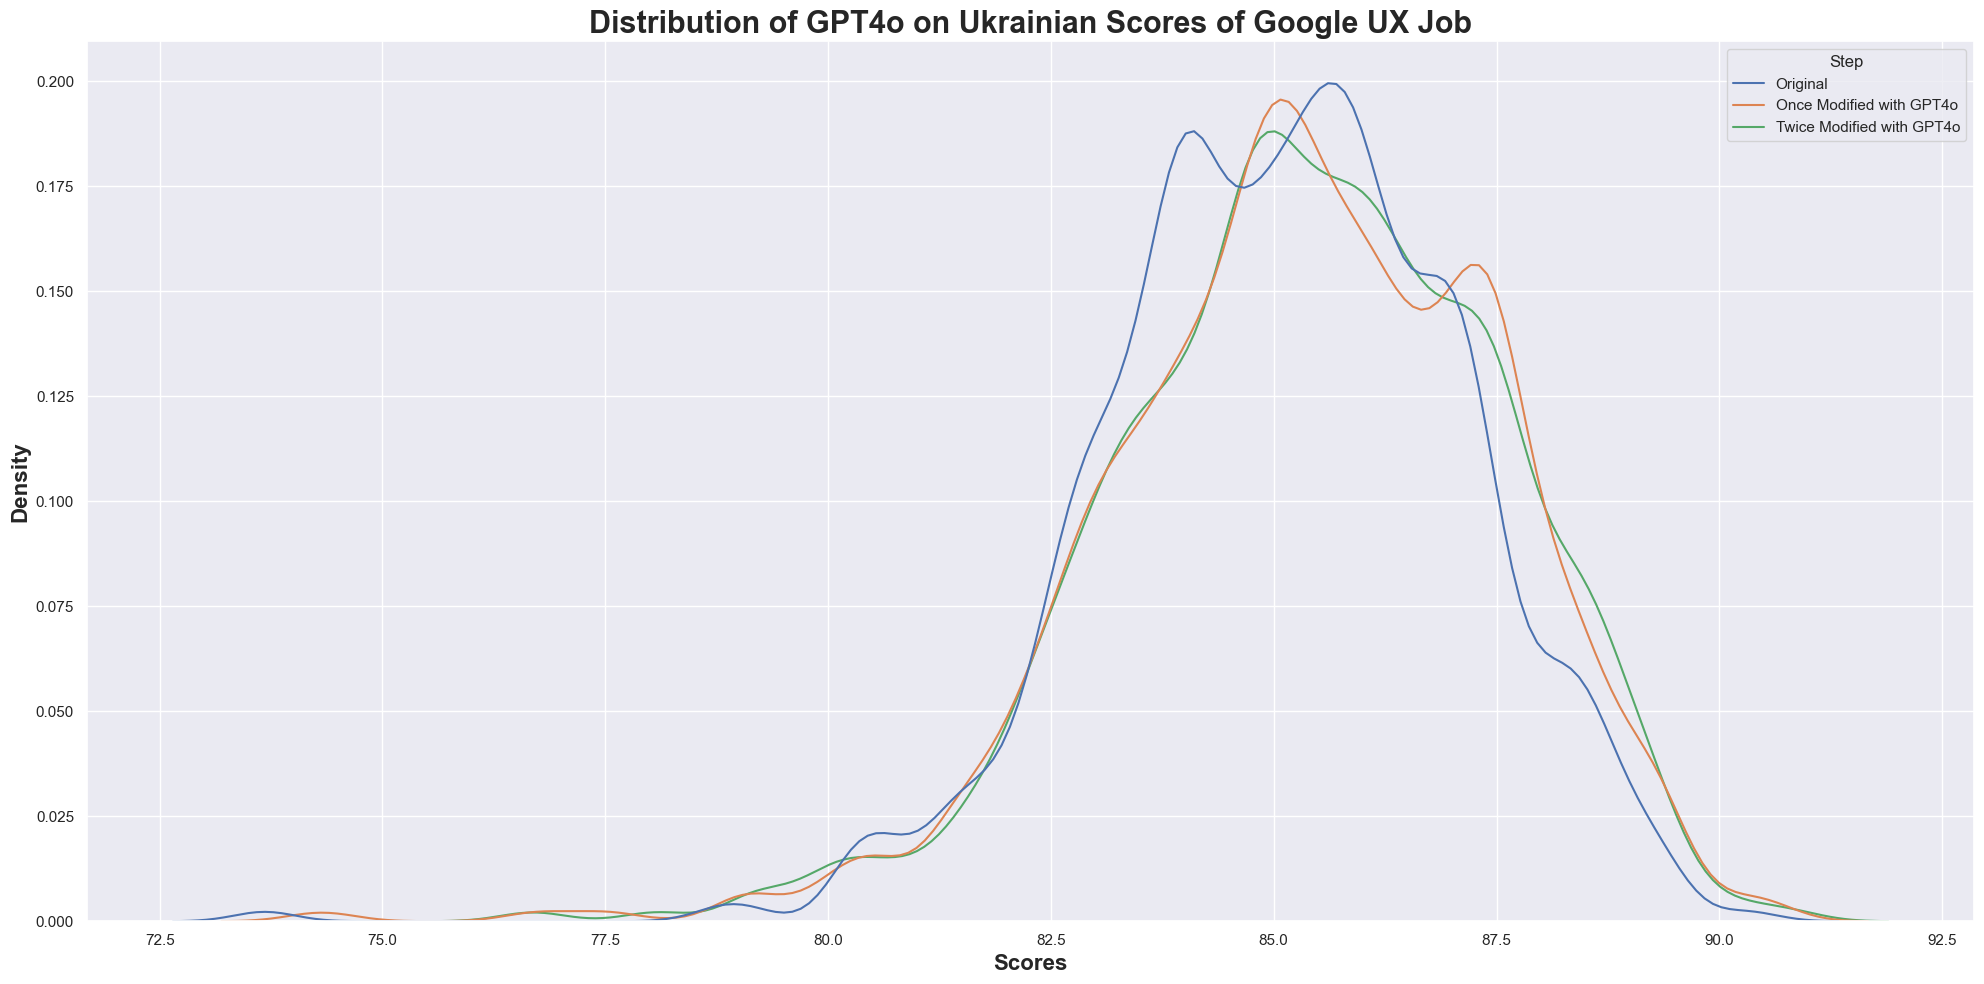

In [2413]:
plot3_steps = [
    {"label": "Original",        "path": "/Users/nicky/Desktop/FACT/Nicky/Ukrainian/ScoresGoogle_Original_File_uiux_pm_520.csv",      "col": 1},
    {"label": "Once Modified with GPT4o",  "path": "/Users/nicky/Desktop/FACT/Nicky/Ukrainian/ScoresGoogle_Original_File_merged_gpt-4o_UK.csv",   "col": 1},
    {"label": "Twice Modified with GPT4o",       "path": '/Users/nicky/Desktop/FACT/Nicky/Ukrainian/ScoresGoogle_Original_File_merged_gpt-4o2_UK.csv',      "col": 1},
]

plot_pipeline_kde(
    plot3_steps,
    title="Distribution of GPT4o on Ukrainian Scores of Google UX Job",
)